In [8]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
_src = str(Path(globals()['__vsc_ipynb_file__']).parents[2])
if _src not in sys.path:
    sys.path.insert(0, _src)

In [9]:
from utils.plot_config import set_korean_font

warnings.filterwarnings('ignore')
# sns.set_theme() 이 rcParams 를 초기화하므로 먼저 호출한 뒤 set_korean_font() 를 적용
sns.set_theme(style='white', palette='muted')
set_korean_font()

COLORS = {0: '#1f77b4', 1: '#ff7f0e'}

[PLOT_CONFIG] OS='Windows' → 'Malgun Gothic' font will be used for Korean text.


## 1. 데이터 로드


In [10]:
df = pd.read_csv('../../data/processed/ljh_preprocessed.csv')
df.head()

,user_id,country_id,gender,age_group,reg_date,first_deposit,first_bet,fixed_bet_amount,live_bet_amount,total_bet_amount,...,fixed_hit_days,live_hit_days,total_hit_days,fixed_win_rate,live_win_rate,total_win_rate,fixed_avg_roi,live_avg_roi,total_avg_roi,churn
0,1324354,276.0,1.0,3.0,2005-02-01,2005-02-24,2005-02-24,15750.38,2146.47,17896.85,...,93.0,22.0,29.0,0.24,0.42,0.27,-0.00,-0.09,-0.08,0
1,1324355,300.0,1.0,1.0,2005-02-01,2005-02-01,2005-02-01,639.30,24.70,664.00,...,15.0,1.0,1.0,0.14,0.14,0.20,0.17,-0.76,-0.77,0
2,1324356,276.0,1.0,2.0,2005-02-01,2005-02-01,2005-02-02,898.81,701.82,1600.63,...,12.0,18.0,18.0,0.12,0.26,0.33,0.38,-0.25,0.64,0
3,1324358,752.0,1.0,1.0,2005-02-01,2005-02-01,2005-02-01,247.70,88.59,336.29,...,1.0,1.0,1.0,0.00,0.00,0.00,-0.88,-0.37,-0.54,1
4,1324360,792.0,1.0,2.0,2005-02-01,2005-02-02,2005-02-02,685.94,6.66,692.61,...,14.0,2.0,3.0,0.14,0.25,0.50,0.89,-0.63,6.99,0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46339 entries, 0 to 46338
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            46339 non-null  int64  
 1   country_id         46337 non-null  float64
 2   gender             46337 non-null  float64
 3   age_group          46337 non-null  float64
 4   reg_date           46337 non-null  str    
 5   first_deposit      46337 non-null  str    
 6   first_bet          46337 non-null  str    
 7   fixed_bet_amount   46337 non-null  float64
 8   live_bet_amount    46337 non-null  float64
 9   total_bet_amount   46337 non-null  float64
 10  fixed_win_amount   46337 non-null  float64
 11  live_win_amount    46337 non-null  float64
 12  total_win_amount   46337 non-null  float64
 13  fixed_bet_cnt      46337 non-null  float64
 14  live_bet_cnt       46337 non-null  float64
 15  total_bet_cnt      46337 non-null  float64
 16  fixed_active_days  46337 non-null

In [12]:
df.describe()

,user_id,country_id,gender,age_group,fixed_bet_amount,live_bet_amount,total_bet_amount,fixed_win_amount,live_win_amount,total_win_amount,...,fixed_hit_days,live_hit_days,total_hit_days,fixed_win_rate,live_win_rate,total_win_rate,fixed_avg_roi,live_avg_roi,total_avg_roi,churn
count,4.633900e+04,46337.000000,46337.000000,46337.00000,46337.000000,46337.000000,46337.000000,46337.00000,46337.000000,46337.000000,...,45609.000000,31402.000000,28164.000000,45609.000000,31402.000000,28164.000000,45609.000000,31402.000000,28164.000000,46339.000000
mean,1.365008e+06,362.231457,0.919093,1.97065,1192.921425,1577.878537,2770.799993,1038.62267,1473.088319,2511.710982,...,15.893639,15.869626,13.879172,0.178540,0.330293,0.301053,-0.267395,-0.261136,0.320296,0.280908
std,2.322630e+04,193.114762,0.272696,1.02184,5124.679464,13279.839039,15987.791697,4795.08205,12660.658539,15088.095514,...,31.276931,38.372436,31.062806,0.152304,0.261951,0.262280,20.896053,0.674325,37.529711,0.449448
min,1.324354e+06,8.000000,0.000000,0.00000,0.000000,0.000000,0.040000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,1.345069e+06,276.000000,1.000000,1.00000,68.300000,0.000000,98.790000,26.72000,0.000000,49.430000,...,1.000000,1.000000,1.000000,0.040000,0.120000,0.000000,-0.810000,-0.560000,-0.460000,0.000000
50%,1.365092e+06,276.000000,1.000000,2.00000,216.680000,20.000000,305.440000,152.36000,10.400000,227.710000,...,5.000000,4.000000,4.000000,0.170000,0.330000,0.300000,-0.450000,-0.250000,-0.160000,0.000000
75%,1.385062e+06,300.000000,1.000000,3.00000,699.410000,175.820000,1040.010000,574.41000,145.290000,883.730000,...,17.000000,13.000000,12.000000,0.270000,0.500000,0.450000,-0.160000,-0.050000,0.090000,1.000000
max,1.405190e+06,891.000000,1.000000,8.00000,380093.970000,746243.350000,843123.650000,420949.25000,723318.790000,812114.250000,...,543.000000,546.000000,525.000000,1.000000,1.000000,1.000000,4455.210000,44.230000,6204.080000,1.000000


In [13]:
from sklearn.model_selection import train_test_split

df = df.drop(['reg_date','first_deposit','first_bet','user_id','country_id'],axis=1)

X = df.drop('churn',axis=1)
y = df['churn']

zero_cols = [
    'fixed_hit_days', 'live_hit_days', 'total_hit_days',
    'fixed_win_rate', 'live_win_rate', 'total_win_rate',
    'fixed_avg_roi', 'live_avg_roi', 'total_avg_roi'
]
X[zero_cols] = X[zero_cols].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,stratify=y)


In [14]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 46339 entries, 0 to 46338
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             46337 non-null  float64
 1   age_group          46337 non-null  float64
 2   fixed_bet_amount   46337 non-null  float64
 3   live_bet_amount    46337 non-null  float64
 4   total_bet_amount   46337 non-null  float64
 5   fixed_win_amount   46337 non-null  float64
 6   live_win_amount    46337 non-null  float64
 7   total_win_amount   46337 non-null  float64
 8   fixed_bet_cnt      46337 non-null  float64
 9   live_bet_cnt       46337 non-null  float64
 10  total_bet_cnt      46337 non-null  float64
 11  fixed_active_days  46337 non-null  float64
 12  live_active_days   46337 non-null  float64
 13  total_active_days  46337 non-null  float64
 14  fixed_hit_days     46339 non-null  float64
 15  live_hit_days      46339 non-null  float64
 16  total_hit_days     46339 non-null

In [15]:
from sklearn.tree import DecisionTreeClassifier    

dt_clf = DecisionTreeClassifier(random_state=0)
dt_clf = DecisionTreeClassifier(random_state=0,max_depth=3)
dt_clf.fit(X_train,y_train)

dt_clf.score(X_train,y_train), dt_clf.score(X_test,y_test)

(0.804943315877309, 0.8059559775571861)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(max_depth=7, random_state=0)

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))

from sklearn.metrics import confusion_matrix, accuracy_score,roc_auc_score, classification_report, roc_curve, recall_score, precision_score

y_pred = rf_clf.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print('precision :',precision_score(y_test,y_pred))
print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',recall_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.817920239396904 평가 점수 : 0.8081139404402244
[[7629  702]
 [1521 1733]]
precision : 0.7117043121149897
accuracy score : 0.8081139404402244
recall_score : 0.5325752919483713
f1_score : 0.5325752919483713
roc_auc_score : 0.7241558490710527
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      8331
           1       0.71      0.53      0.61      3254

    accuracy                           0.81     11585
   macro avg       0.77      0.72      0.74     11585
weighted avg       0.80      0.81      0.80     11585



total_active_days    0.303597
fixed_active_days    0.191268
total_bet_cnt        0.097049
fixed_bet_cnt        0.080864
fixed_hit_days       0.073643
fixed_bet_amount     0.057297
total_bet_amount     0.037614
fixed_win_rate       0.026919
fixed_win_amount     0.024372
total_win_amount     0.019004
dtype: float64


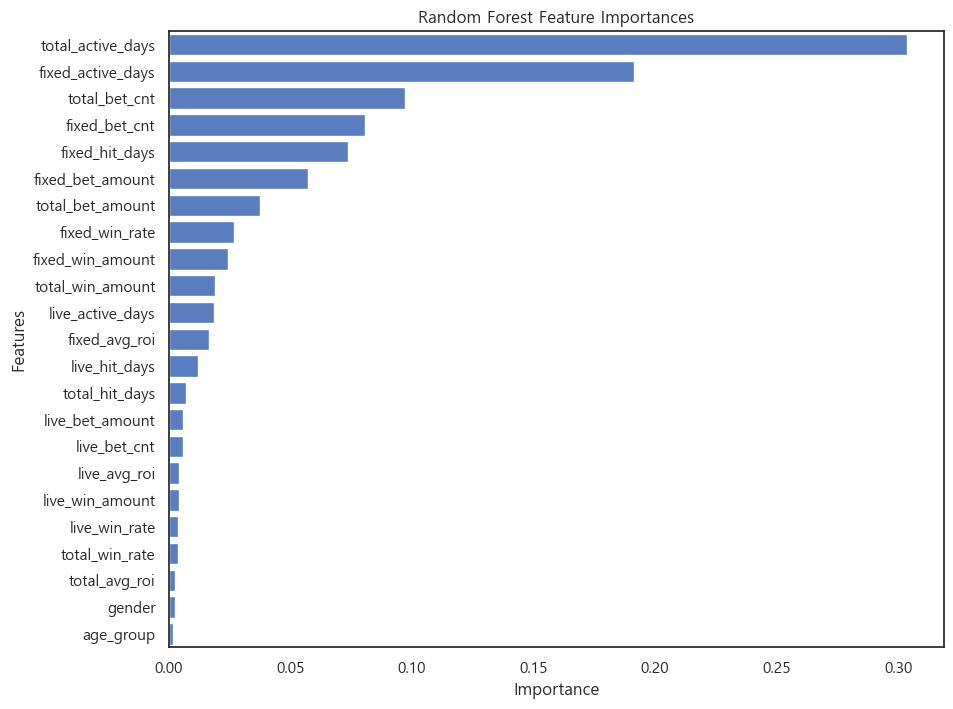

In [17]:
feat_impt_ser = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 2. 결과 출력
print(feat_impt_ser.head(10))

# 3. 시각화 
plt.figure(figsize=(10, 8))
sns.barplot(x=feat_impt_ser, y=feat_impt_ser.index)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

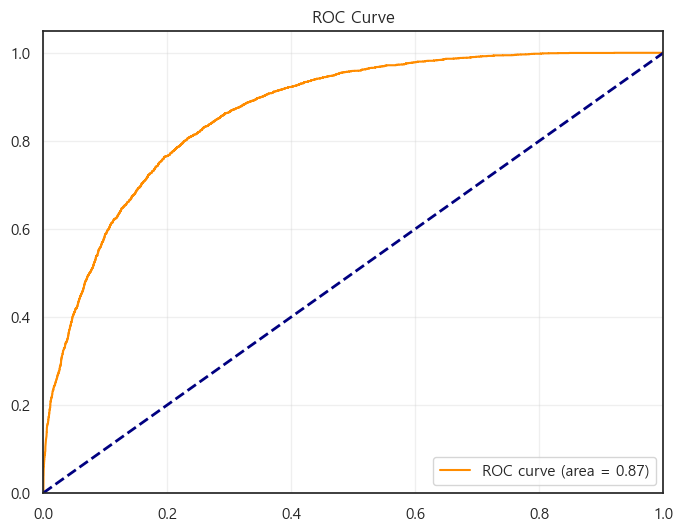

최종 AUC 점수: 0.8678


In [18]:
y_pred_proba = rf_clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"최종 AUC 점수: {auc_score:.4f}")


In [19]:
from sklearn.model_selection import GridSearchCV

params = {
'n_estimators': [100, 150, 200], 
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV 실행
grid = GridSearchCV(rf_clf, params, scoring='recall', cv=5)

grid.fit(X_train,y_train)

KeyboardInterrupt: 

In [ ]:
grid.best_params_

{'max_depth': 9, 'min_samples_split': 5, 'n_estimators': 150}

In [ ]:
grid.best_score_

np.float64(0.54542890089228)

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=9,
    min_samples_split=5,
    random_state=0
    )

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))
y_train_pred = rf_clf.predict(X_train)

from sklearn.metrics import accuracy_score,roc_auc_score, classification_report, roc_curve, recall_score, f1_score

y_pred = rf_clf.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print('precision :',precision_score(y_test,y_pred))
print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('train_f1_score :',f1_score(y_train, y_train_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.8343787765437072 평가 점수 : 0.8094087181700474
[[7604  727]
 [1481 1773]]
precision : 0.7092
accuracy score : 0.8094087181700474
recall_score : 0.5448678549477566
f1_score : 0.616266944734098
train_f1_score : 0.6656598513011153
roc_auc_score : 0.7288017104531125
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      8331
           1       0.71      0.54      0.62      3254

    accuracy                           0.81     11585
   macro avg       0.77      0.73      0.74     11585
weighted avg       0.80      0.81      0.80     11585



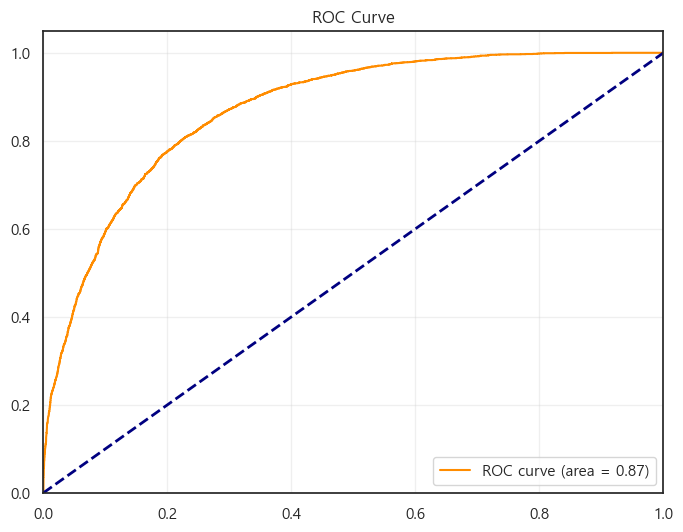

최종 AUC 점수: 0.8714


In [ ]:
y_pred_proba = rf_clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"최종 AUC 점수: {auc_score:.4f}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 파라미터 범위 설정
params = {
    'n_estimators': range(100, 501, 50),     
    'max_depth': range(3, 21, 2),            
    'min_samples_split': range(2, 21, 2)      
}


rd_search = RandomizedSearchCV(
    rf_clf, 
    param_distributions=params, 
    n_iter=15, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1, 
    random_state=42,
    verbose=1  
)

# 학습
rd_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': range(3, 21, 2), 'min_samples_split': range(2, 21, 2), 'n_estimators': range(100, 501, 50)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``

In [ ]:
print(rd_search.best_params_)
print(rd_search.best_estimator_)
print(rd_search.best_score_)

{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 17}
RandomForestClassifier(max_depth=17, min_samples_split=10, n_estimators=300,
                       random_state=0)
0.5708294511176584


In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=10,
    max_depth=17,
    random_state=0
    )

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))

from sklearn.metrics import accuracy_score,roc_auc_score, classification_report, roc_curve, recall_score, f1_score

y_pred = rf_clf.predict(X_test)

print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.9170167462738102 평가 점수 : 0.8135520069054812
accuracy score : 0.8135520069054812
recall_score : 0.5694529809465273
f1_score : 0.6317763382202523
roc_auc_score : 0.7391737357019277
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      8331
           1       0.71      0.57      0.63      3254

    accuracy                           0.81     11585
   macro avg       0.78      0.74      0.75     11585
weighted avg       0.81      0.81      0.81     11585



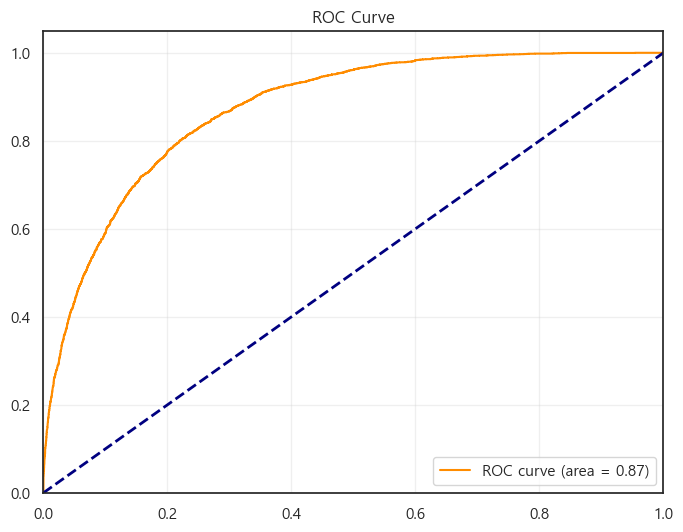

최종 AUC 점수: 0.8733


In [ ]:
y_pred_proba = rf_clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"최종 AUC 점수: {auc_score:.4f}")

In [ ]:
# !pip install hyperopt

In [ ]:
import numpy as np
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import recall_score

# 1. 탐색 공간(Search Space) 정의
search_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 20, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1)
}

def objective(space):
    model = RandomForestClassifier(
        n_estimators=int(space['n_estimators']),
        max_depth=int(space['max_depth']),
        min_samples_split=int(space['min_samples_split']),
        min_samples_leaf=int(space['min_samples_leaf']),
        n_jobs=-1,
        random_state=42
    )
    
    # 교차 검증 수행 (Recall 기준)
    # Hyperopt는 '최소값'을 찾으므로 Recall에 -1을 곱해 'Loss'로 계산합니다.
    accuracy = cross_val_score(model, X_train, y_train, cv=5, scoring='recall').mean()
    
    return {'loss': -accuracy, 'status': STATUS_OK}

# 3. 최적화 실행
trials = Trials()
best_val = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,  
    trials=trials
)

print(f"\n최적의 파라미터 인덱스/값: {best_val}")

# 4. 최적의 파라미터로 최종 모델 학습
# fmin 결과는 float로 나오므로 다시 int로 감싸서 넣어줍니다.
best_rf = RandomForestClassifier(
    n_estimators=int(best_val['n_estimators']),
    max_depth=int(best_val['max_depth']),
    min_samples_split=int(best_val['min_samples_split']),
    min_samples_leaf=int(best_val['min_samples_leaf']),
    n_jobs=-1,
    random_state=42
)

best_rf.fit(X_train, y_train)
y_train_pred = best_rf.predict(X_train)

# 5. 테스트 데이터로 최종 평가
y_pred = best_rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print('accuracy score :',accuracy_score(y_test, y_pred))
print('precision_score :',precision_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('Train_f1_score :',f1_score(y_train, y_train_pred))
print(classification_report(y_test, y_pred))

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 50/50 [09:36<00:00, 11.53s/trial, best loss: -0.5701129200137662]

최적의 파라미터 인덱스/값: {'max_depth': np.float64(19.0), 'min_samples_leaf': np.float64(1.0), 'min_samples_split': np.float64(12.0), 'n_estimators': np.float64(350.0)}
[[7567  764]
 [1390 1864]]
accuracy score : 0.8140699179974105
precision_score : 0.7092846270928462
recall_score : 0.5728334357713584
roc_auc_score : 0.7405638790908166
f1_score : 0.6337980278816729
Train_f1_score : 0.850920545266931
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      8331
           1       0.71      0.57      0.63      3254

    accuracy                           0.81     11585
   macro avg       0.78      0.74      0.75     11585
weighted avg       0.81      0.81      0.81     11585



In [ ]:
best_rf.score(X_train,y_train),best_rf.score(X_test,y_test)

(0.9210162858951487, 0.8140699179974105)

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=350,
    min_samples_split=12,
    max_depth=19,
    min_samples_leaf=1,
    random_state=42
    )

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))

from sklearn.metrics import accuracy_score,roc_auc_score, classification_report,  recall_score, f1_score

y_pred = rf_clf.predict(X_test)

print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.9210162858951487 평가 점수 : 0.8140699179974105
accuracy score : 0.8140699179974105
recall_score : 0.5728334357713584
f1_score : 0.6337980278816729
roc_auc_score : 0.7405638790908166
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      8331
           1       0.71      0.57      0.63      3254

    accuracy                           0.81     11585
   macro avg       0.78      0.74      0.75     11585
weighted avg       0.81      0.81      0.81     11585



In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=17,
    max_depth=19,
    min_samples_leaf=2,
    random_state=42
    )

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))

from sklearn.metrics import accuracy_score,roc_auc_score, classification_report,  recall_score, f1_score

y_pred = rf_clf.predict(X_test)

print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.8990044311446165 평가 점수 : 0.8142425550280535
accuracy score : 0.8142425550280535
recall_score : 0.5759065765212047
f1_score : 0.6352542372881356
roc_auc_score : 0.7416203150280973
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      8331
           1       0.71      0.58      0.64      3254

    accuracy                           0.81     11585
   macro avg       0.78      0.74      0.76     11585
weighted avg       0.81      0.81      0.81     11585



In [ ]:
# 개선
rf_clf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=30,
    max_depth=21,
    min_samples_leaf=2,
    random_state=0
    )

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))

from sklearn.metrics import accuracy_score,roc_auc_score, classification_report, recall_score, f1_score

y_pred = rf_clf.predict(X_test)

print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.8762444610692295 평가 점수 : 0.8150194216659473
accuracy score : 0.8150194216659473
recall_score : 0.5734480639213276
f1_score : 0.6352340425531915
roc_auc_score : 0.7414113444081492
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      8331
           1       0.71      0.57      0.64      3254

    accuracy                           0.82     11585
   macro avg       0.78      0.74      0.76     11585
weighted avg       0.81      0.82      0.81     11585



total_active_days    0.203918
fixed_active_days    0.146626
fixed_bet_cnt        0.095297
total_bet_cnt        0.080843
fixed_bet_amount     0.062941
total_bet_amount     0.050620
fixed_hit_days       0.047549
fixed_win_amount     0.043885
fixed_avg_roi        0.038475
total_win_amount     0.037631
dtype: float64


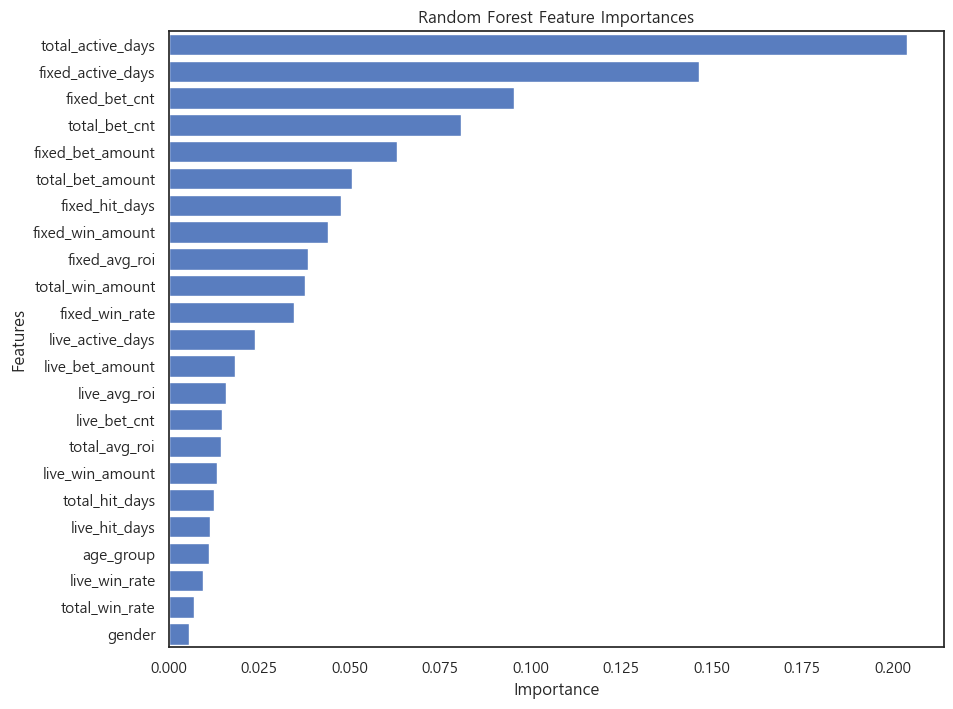

In [ ]:
feat_impt_ser = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 2. 결과 출력
print(feat_impt_ser.head(10))

# 3. 시각화 
plt.figure(figsize=(10, 8))
sns.barplot(x=feat_impt_ser, y=feat_impt_ser.index)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [ ]:
# !pip install optuna

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. 탐색할 하이퍼파라미터 범위 정의
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 0,
        'n_jobs': -1
    }

    # 2. 모델 생성 및 교차 검증
    rf = RandomForestClassifier(**param)
    
    # 이탈 분석이므로 scoring은 'recall'로 설정
    score = cross_val_score(rf, X_train, y_train, cv=5, scoring='recall').mean()
    
    return score

# 3. Study 객체 생성 및 최적화 수행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) 

print(f"최적의 Recall 점수: {study.best_value}")
print(f"최적의 파라미터: {study.best_params}")

[I 2026-02-24 00:02:44,210] A new study created in memory with name: no-name-28ddccce-458d-4ff4-b376-88c013579a7b
[I 2026-02-24 00:02:49,971] Trial 0 finished with value: 0.5578221924235937 and parameters: {'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.5578221924235937.
[I 2026-02-24 00:03:04,728] Trial 1 finished with value: 0.5494234909722746 and parameters: {'n_estimators': 450, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.5578221924235937.
[I 2026-02-24 00:03:11,633] Trial 2 finished with value: 0.5675519167652959 and parameters: {'n_estimators': 150, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.5675519167652959.
[I 2026-02-24 00:03:27,879] Trial 3 finished with value: 0.5663230905794364 and parameters: {'n_estimators': 450, 'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 10}. Best is trial 2 with va

최적의 Recall 점수: 0.5704204019876944
최적의 파라미터: {'n_estimators': 400, 'max_depth': 23, 'min_samples_split': 19, 'min_samples_leaf': 2}


In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    min_samples_split=19,
    max_depth=23,
    min_samples_leaf=2,
    random_state=0
    )

rf_clf.fit(X_train, y_train)

print("훈련 점수 :",rf_clf.score(X_train, y_train), "평가 점수 :",rf_clf.score(X_test, y_test))

from sklearn.metrics import accuracy_score,roc_auc_score, classification_report, roc_curve, recall_score, f1_score

y_pred = rf_clf.predict(X_test)

print('accuracy score :',accuracy_score(y_test, y_pred))
print('recall_score :',recall_score(y_test, y_pred))
print('f1_score :',f1_score(y_test, y_pred))
print('roc_auc_score :',roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

훈련 점수 : 0.8998388674684928 평가 점수 : 0.8145015105740181
accuracy score : 0.8145015105740181
recall_score : 0.5725261216963737
f1_score : 0.6342127659574468
roc_auc_score : 0.7407703228815562
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      8331
           1       0.71      0.57      0.63      3254

    accuracy                           0.81     11585
   macro avg       0.78      0.74      0.75     11585
weighted avg       0.81      0.81      0.81     11585



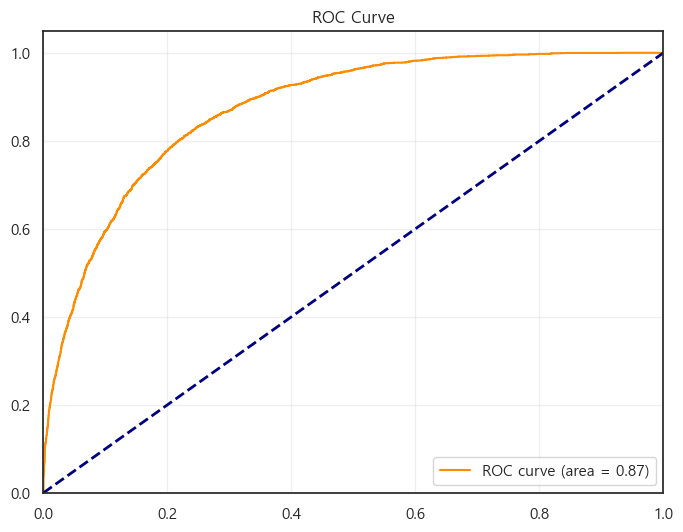

최종 AUC 점수: 0.8735


In [ ]:
y_pred_proba = rf_clf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"최종 AUC 점수: {auc_score:.4f}")

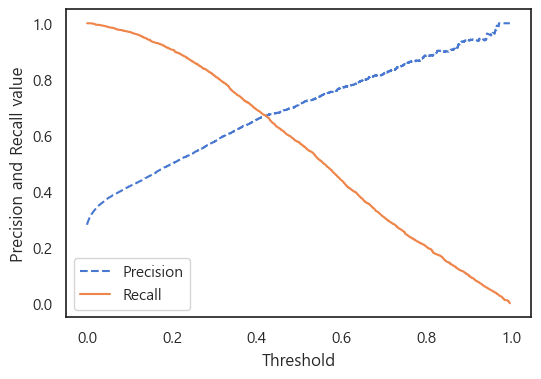

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], linestyle='--', label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Precision and Recall value')
plt.legend()
plt.show()

In [20]:
from src.utils.model_manager import ModelManager
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# 1. 모델 매니저 초기화 (최상위 'models' 폴더 기준)
mm = ModelManager(base_dir='..')

# 2. 최종 모델(6.1 실험 모델)의 예측값 생성 (메타데이터 기록용)
y_pred = rf_clf.predict(X_test)
y_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

# 3. 저장할 폴더명 설정 (규칙: 사용자명/사용자명_모델명_v1)
# 이렇게 설정하면 models/psy/psy_RF_Churn_v1/ 경로에 저장됩니다.
save_path = 'psy/psy_RF_Churn_v1'

# 4. 모델 및 메타데이터 저장
mm.save(
    rf_clf, 
    save_path, 
    metadata={
        'accuracy': accuracy_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'best_params': {
            'n_estimators': 500,
            'max_depth': 21,
            'min_samples_split': 30,
            'min_samples_leaf': 2,
            'random_state': 42
        },
        'data': 'data/processed/sports_betting_churn.csv', # 사용하신 데이터 경로
        'random_state': 42,
        'description': '6.1 추가 실험을 통해 과적합을 개선한 수동 튜닝 모델'
    }
)

print(f"✅ 모델 저장 완료: models/{save_path}/")

[Model Manager]: psy/psy_RF_Churn_v1 saved successfully (671.1 KB)
✅ 모델 저장 완료: models/psy/psy_RF_Churn_v1/
